In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
data = pd.read_csv("AI_Impact_on_Jobs_2030.csv")

In [4]:
data.head(8)

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42
5,AI Engineer,92592,11,Master's,0.29,0.51,0.10,Low,0.71,0.79,0.61,0.93,0.65,0.91,0.85,0.45,0.10,0.37
6,Mechanic,107373,23,PhD,0.67,1.09,0.41,Medium,0.56,0.38,0.97,0.85,0.72,0.24,0.26,0.04,0.71,0.11
7,Teacher,53419,12,High School,0.20,1.40,0.17,Low,0.56,0.70,0.14,0.60,0.54,0.20,0.94,0.60,0.69,0.88


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 13  Skill_6           

In [6]:
data.describe().round(2)

,Average_Salary,Years_Experience,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,89372.28,14.68,0.50,1.00,0.50,0.50,0.50,0.50,0.50,0.49,0.50,0.50,0.50,0.50,0.49
std,34608.09,8.74,0.28,0.29,0.25,0.29,0.29,0.29,0.29,0.29,0.29,0.29,0.29,0.29,0.29
min,30030.00,0.00,0.00,0.50,0.05,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,58640.00,7.00,0.26,0.74,0.31,0.24,0.25,0.25,0.26,0.24,0.26,0.25,0.25,0.26,0.25
50%,89318.00,15.00,0.50,1.00,0.50,0.50,0.50,0.50,0.51,0.49,0.50,0.49,0.50,0.50,0.49
75%,119086.50,22.00,0.74,1.24,0.70,0.74,0.74,0.75,0.75,0.73,0.74,0.75,0.75,0.74,0.74
max,149798.00,29.00,1.00,1.50,0.95,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [7]:
data.shape

(3000, 18)

In [8]:
data.duplicated().sum()

np.int64(0)

In [8]:
skills_cols = [col for col in data.columns if "Skill_" in col]
data["Average_Skill"] = data[skills_cols].mean(axis=1)

In [12]:
data = data.drop(columns = skills_cols)

In [14]:
data.head()

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Average_Skill
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.385
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.426
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.451
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.492
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.465


A. Distribution of Risk Categories
Understanding of how many jobs fall into each level of AI automation risk in the dataset


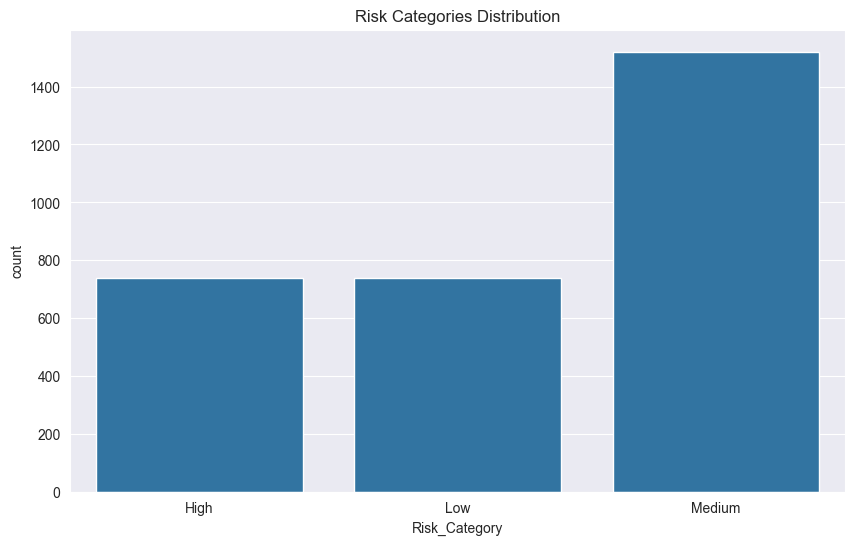

In [62]:
plt.figure(figsize=(10, 6))
plt.title("Risk Categories Distribution")
sns.countplot(x='Risk_Category', data=data)
print("A. Distribution of Risk Categories")
print("Understanding of how many jobs fall into each level of AI automation risk in the dataset")

B. Salary Distribution
Examines whether salaries are evenly distributed or concentrated in specific ranges.


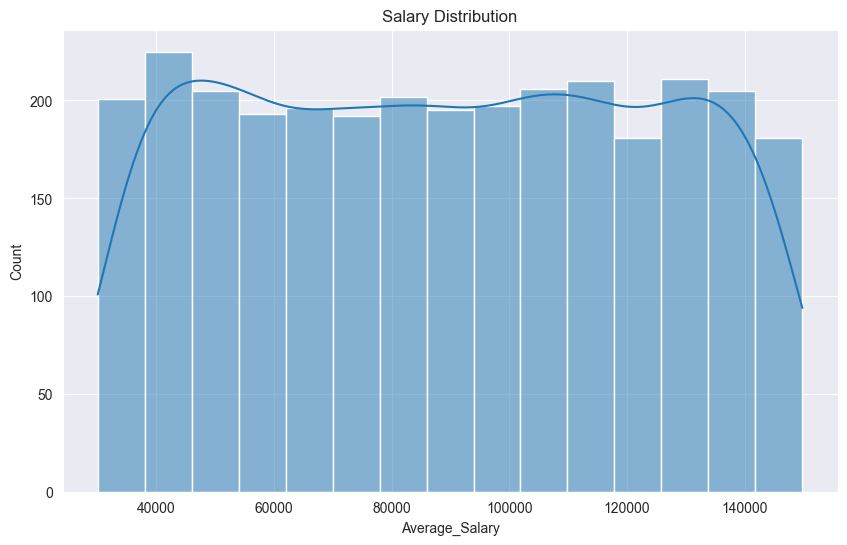

In [63]:
plt.figure(figsize=(10, 6))
plt.title("Salary Distribution")
sns.histplot(data['Average_Salary'], kde=True)
print("B. Salary Distribution")
print("Examines whether salaries are evenly distributed or concentrated in specific ranges.")

C. AI Exposure vs Automation Probability
Highlights the relation between AI exposure and the probability of job automation by 2030. Visualize wherthe jobs with higher AI exposure tend to have higher automation risk


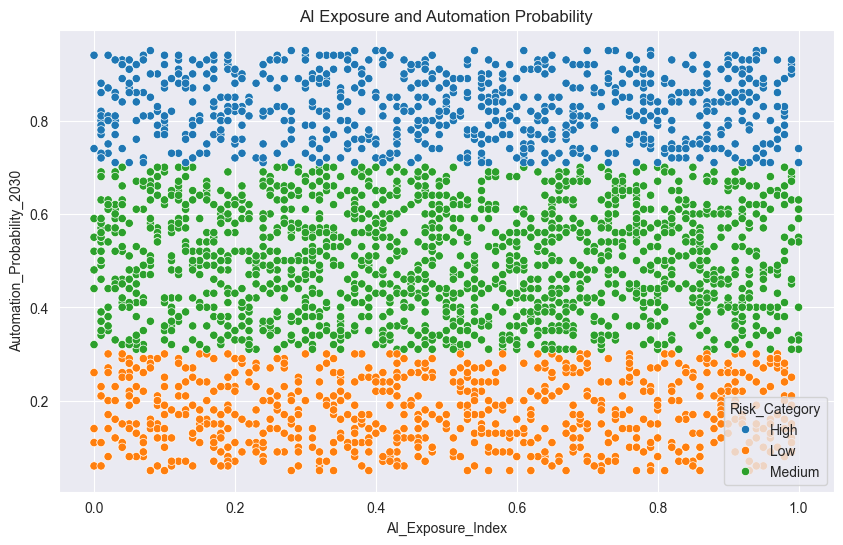

In [64]:
plt.figure(figsize=(10, 6))
plt.title("AI Exposure and Automation Probability")
sns.scatterplot(data = data, x="AI_Exposure_Index", y = "Automation_Probability_2030", hue = "Risk_Category")
print("C. AI Exposure vs Automation Probability")
print("Highlights the relation between AI exposure and the probability of job automation by 2030. Visualize wherthe jobs with higher AI exposure tend to have higher automation risk")

D. Experience vs Automation Risk
Understanding whether more experienced workers tend to have lower or higher automation risk.


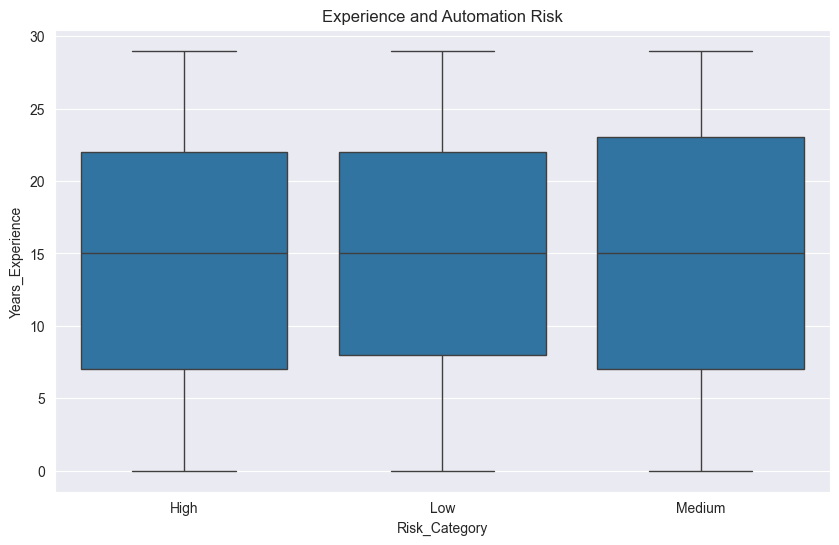

In [65]:
plt.figure(figsize=(10, 6))
plt.title("Experience and Automation Risk")
sns.boxplot(data = data, x="Risk_Category", y="Years_Experience")
print("D. Experience vs Automation Risk")
print("Understanding whether more experienced workers tend to have lower or higher automation risk.")

E. Education Level Analysis
Highlights the job automation probabilty based on education level.


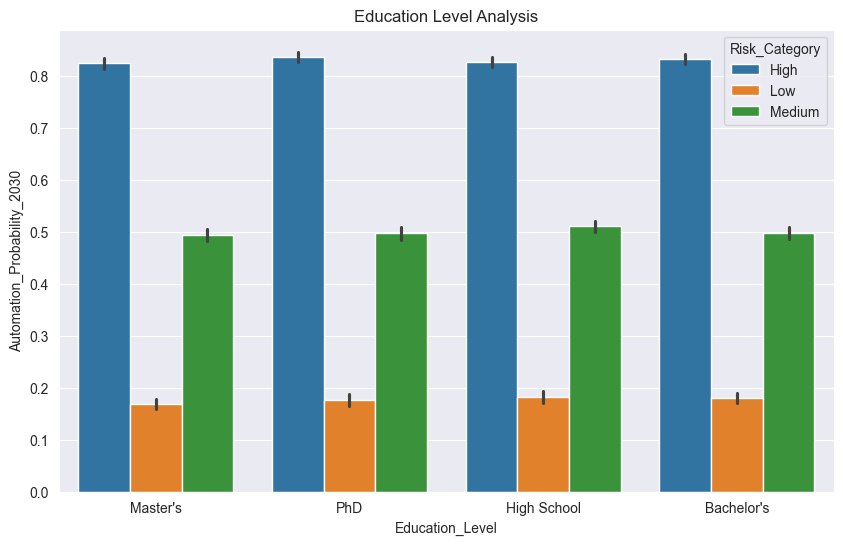

In [66]:
plt.figure(figsize=(10, 6))
plt.title("Education Level Analysis")
sns.barplot(data=data, x="Education_Level", y="Automation_Probability_2030", hue="Risk_Category")
print("E. Education Level Analysis")
print("Highlights the job automation probabilty based on education level.")

F. Correlation Heatmap
Highlights correlation between all numerical features in the dataset.


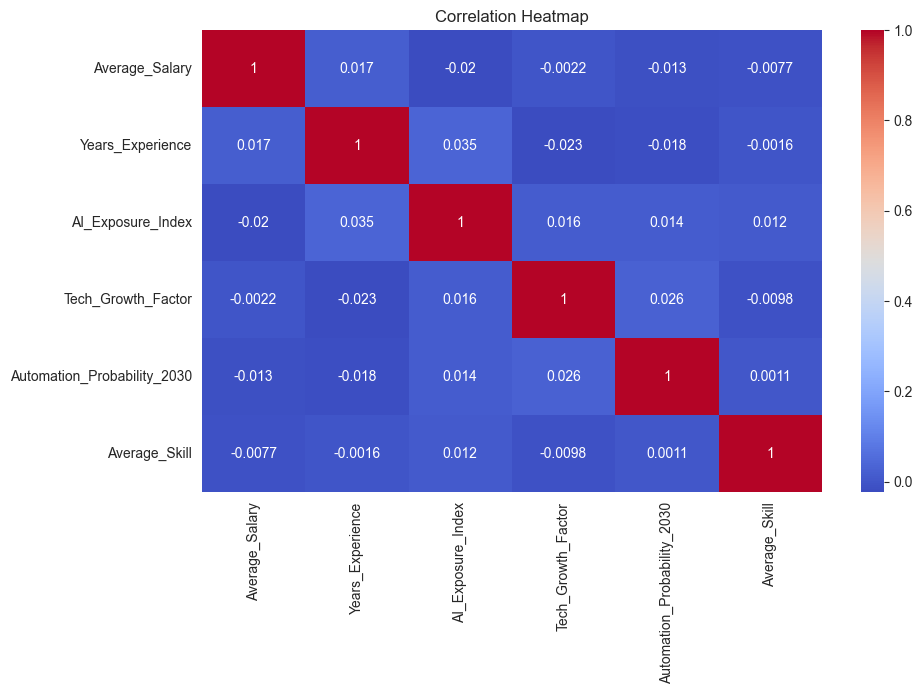

In [67]:
plt.figure(figsize=(10, 6))
plt.title("Correlation Heatmap")
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
print("F. Correlation Heatmap")
print("Highlights correlation between all numerical features in the dataset.")

In [98]:
bachelor_data=data[data["Education_Level"] == "Bachelor's"]
safe_bachelor_jobs = bachelor_data.groupby("Job_Title").agg({"Automation_Probability_2030":"mean", "Average_Salary":"mean"}).sort_values(by="Automation_Probability_2030").head(10)
print("Top 10 Safest Job (Education Level: Bachelor's)")
safe_bachelor_jobs.round(2)

Top 10 Safest Job (Education Level: Bachelor's)


,Automation_Probability_2030,Average_Salary
Job_Title,,
Research Scientist,0.17,76186.48
Doctor,0.18,96382.65
Teacher,0.18,87182.81
Nurse,0.18,82079.05
AI Engineer,0.19,96442.18
Chef,0.44,90665.51
UX Researcher,0.47,93852.95
Marketing Manager,0.49,89410.96
Financial Analyst,0.49,90263.45


In [99]:
bachelor_data=data[data["Education_Level"] == "Bachelor's"]
risk_bachelor_jobs = bachelor_data.groupby("Job_Title").agg({"Automation_Probability_2030":"mean", "Average_Salary":"mean"}).sort_values(by="Automation_Probability_2030", ascending=False).head(10)
print("Top 10 Under Risk Job (Education Level: Bachelor's)")
risk_bachelor_jobs.round(2)

Top 10 Under Risk Job (Education Level: Bachelor's)


,Automation_Probability_2030,Average_Salary
Job_Title,,
Construction Worker,0.84,94468.91
Retail Worker,0.84,79490.58
Security Guard,0.84,89730.76
Customer Support,0.83,86483.00
Truck Driver,0.80,87564.62
Graphic Designer,0.54,95594.66
Software Engineer,0.53,86426.12
Mechanic,0.52,81974.97
HR Specialist,0.50,87865.16


In [106]:
edu_analysis = data.groupby("Education_Level").agg({"Average_Salary": "mean", "Automation_Probability_2030": "mean"}).sort_values("Automation_Probability_2030")
print("High Paying Degree")
edu_analysis.round(2)

High Paying Degree


,Average_Salary,Automation_Probability_2030
Education_Level,,
Master's,91318.56,0.50
Bachelor's,88815.50,0.50
PhD,89045.58,0.50
High School,88389.29,0.51


Years of Experience vs Average Salary


Text(0.5, 1.0, 'Years of Experience vs Average Salary')

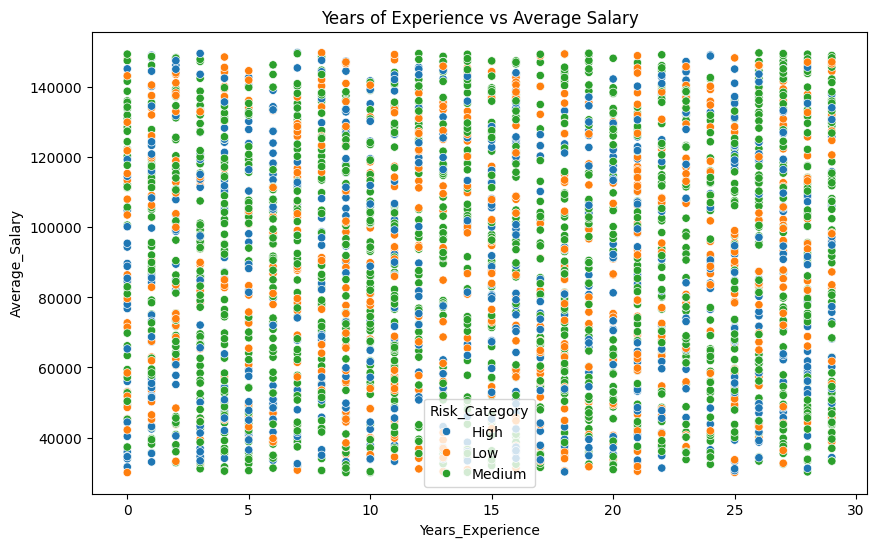

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=data,
    x="Years_Experience",
    y="Average_Salary",
    hue="Risk_Category"
)
print("Years of Experience vs Average Salary")
plt.title("Years of Experience vs Average Salary")

Career Value Analysis
Explores relation between average skill and average salary


<Axes: title={'center': 'Career Value Analysis'}, xlabel='Average_Skill', ylabel='Average_Salary'>

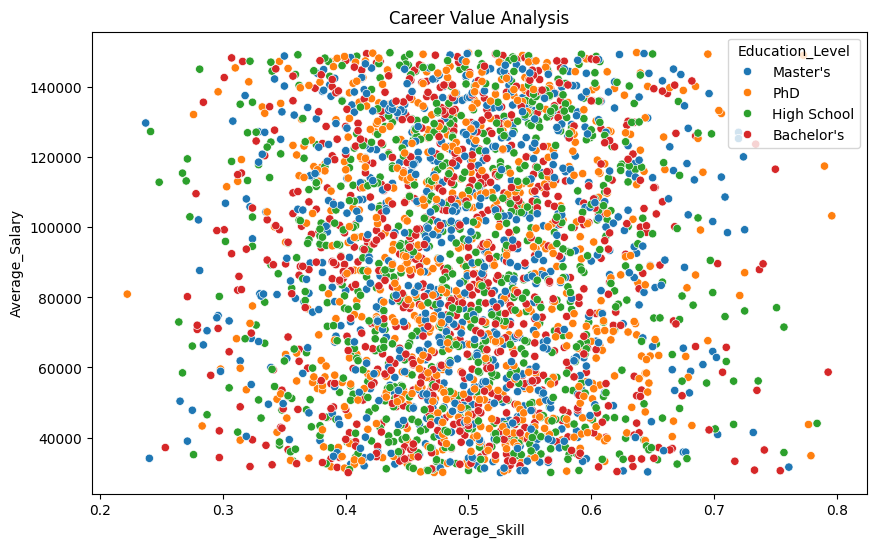

In [10]:
plt.figure(figsize=(10,6))
print("Career Value Analysis")
print("Explores relation between average skill and average salary")
plt.title("Career Value Analysis")
sns.scatterplot(
    data=data,
    x="Average_Skill",
    y="Average_Salary",
    hue="Education_Level"
)